<a href="https://colab.research.google.com/github/Amitosh07/Image-Segmentation-System-project/blob/main/Image_Segmentation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup & Configuration
Imported required libraries (NumPy, Matplotlib, scikit-learn, TensorFlow, Albumentations).

Set random seeds for reproducibility.

Defined constants: number of classes, image size, batch size, and epochs.

Enabled Albumentations.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import datetime
from sklearn.metrics import confusion_matrix, classification_report
USE_ALBU = True
try:
    import albumentations as A
except Exception as e:
    print("albumentations is not available.")
    USE_ALBU = False

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
NUM_CLASSES = 5
IMG_HEIGHT = 128
IMG_WIDTH = 256
BATCH_SIZE = 8 # I have not used batch size = 16 because of my system limitations
EPOCHS = 40

# Loading dataset
Loaded images and masks from .npy files.

Printed dataset shapes for verification.

Displayed class distribution based on pixel counts.

In [ ]:
IMAGES_FILE =  "/content/challenge_images.npy"
MASKS_FILE  =  "/content/challenge_masks.npy"
images = np.load(IMAGES_FILE)
masks = np.load(MASKS_FILE)
print(f"Loaded images shape: {images.shape}")
print(f"Loaded masks shape: {masks.shape}")

unique, counts = np.unique(masks, return_counts=True)
print("Class distribution (pixel counts):", dict(zip(unique.tolist(), counts.tolist())))


Loaded images shape: (1000, 128, 256, 3)
Loaded masks shape: (1000, 128, 256)
Class distribution (pixel counts): {0: 22831765, 1: 6918391, 2: 1122245, 3: 231973, 4: 1663626}


# Dataset Splitting
Computed the dominant class for each mask.

Split the dataset into 70% training, 15% validation, and 15% testing using stratified sampling.

In [ ]:
dominant_class = []
for i in range(len(masks)):
    mask = masks[i].ravel()
    counts = np.bincount(mask, minlength=NUM_CLASSES)
    dominant = counts.argmax()
    dominant_class.append(dominant)

dominant_class = np.array(dominant_class)

# splitting dataset into training [70%], Validation [15%] and testing [15%]
idx = np.arange(len(masks))
train_idx, temp_idx = train_test_split(
    idx,
    test_size=0.30,
    random_state=SEED,
    shuffle=True)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=SEED,
    shuffle=True)

print("Counts -> train:", len(train_idx), "val:", len(val_idx), "test:", len(test_idx))
assert len(train_idx) + len(val_idx) + len(test_idx) == len(masks)


Counts -> train: 700 val: 150 test: 150


# Preprocessing & Augmentation
I have Used Albumentations to apply augmentation techniques such as flips, affine transforms, random cropping, resizing, brightness/contrast variation, and elastic deformation.

Images are normalized to the range [0,1].

Masks are one-hot encoded for multi-class segmentation.

Defined custom generators to yield batches for training, validation, and testing.

In [ ]:
if USE_ALBU:
    train_transform = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.Affine(
                scale=(0.9, 1.1),
                translate_percent=(0.0, 0.0625),
                rotate=(-15, 15),
                p=0.5),
            A.RandomCrop(height=112, width=224, p=0.3),
            A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
            A.RandomBrightnessContrast(p=0.5),
            A.ElasticTransform(p=0.1, alpha=1.0, sigma=50),],
            additional_targets={'mask': 'mask'})
else:
    train_transform = None

def preprocess_image(img):
    img = img.astype(np.float32) / 255.0
    return img

def preprocess_mask(mask):
    mask = mask.astype(np.int32)
    return tf.one_hot(mask, NUM_CLASSES, dtype=tf.float32).numpy()

def train_generator(images, masks, indices, batch_size=BATCH_SIZE, augment=True):
    n = len(indices)
    i = 0
    while True:
        batch_imgs = []
        batch_masks = []
        for b in range(batch_size):
            idx = indices[(i + b) % n]
            img = images[idx]
            msk = masks[idx]
            if augment and USE_ALBU and train_transform is not None:
                augmented = train_transform(image=img, mask=msk)
                img_aug = augmented['image']
                msk_aug = augmented['mask']
            else:
                img_aug = img
                msk_aug = msk
            img_proc = preprocess_image(img_aug)
            msk_proc = preprocess_mask(msk_aug)
            batch_imgs.append(img_proc)
            batch_masks.append(msk_proc)
        i = (i + batch_size) % n
        yield np.stack(batch_imgs, axis=0), np.stack(batch_masks, axis=0)

def val_test_generator(images, masks, indices, batch_size=BATCH_SIZE):
    n = len(indices)
    i = 0
    while True:
        batch_imgs = []
        batch_masks = []
        for b in range(batch_size):
            idx = indices[(i + b) % n]
            img = images[idx]
            msk = masks[idx]
            img_proc = preprocess_image(img)
            msk_proc = preprocess_mask(msk)
            batch_imgs.append(img_proc)
            batch_masks.append(msk_proc)
        i = (i + batch_size) % n
        yield np.stack(batch_imgs, axis=0), np.stack(batch_masks, axis=0)

# Model Architecture
U-Net with ResNet50 backbone

Encoder: ResNet50 pretrained on ImageNet

Decoder: Upsampling + skip connections

Output: Softmax layer for multi-class segmentation

In [ ]:
def conv_block(inputs, filters, kernel_size=3, activation='relu'):
    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    return x

def upsample_concat_block(x, skip, filters):
    x = layers.UpSampling2D((2,2))(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_unet_resnet50(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES):
    base = tf.keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
    skip_names = [
        'conv1_relu',
        'conv2_block3_out',
        'conv3_block4_out',
        'conv4_block6_out',
    ]
    skips = [base.get_layer(name).output for name in skip_names]
    x = base.output

    x = upsample_concat_block(x, skips[3], 512)
    x = upsample_concat_block(x, skips[2], 256)
    x = upsample_concat_block(x, skips[1], 128)
    x = upsample_concat_block(x, skips[0], 64)

    x = layers.UpSampling2D((2,2))(x)
    x = conv_block(x, 32)

    outputs = layers.Conv2D(num_classes, (1,1), padding='same', activation='softmax')(x)
    model = models.Model(inputs=base.input, outputs=outputs)
    return model

model = build_unet_resnet50()
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 262,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 128,   │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 128,   │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 128,   │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 130,   │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 43,974,373 (167.75 MB)

 Trainable params: 43,917,285 (167.53 MB)

 Non-trainable params: 57,088 (223.00 KB)

# Loss & Metrics
**Dice Coefficient**: It Measures overlap between predicted and true masks.

**Dice Loss**: It helps in improving segmentation accuracy.

**Combined Loss**: Cross-entropy + Dice loss for balanced optimization.

**MeanIoU**: Evaluates intersection-over-union across all classes.

**MeanDice**: Computes average Dice score across classes.

In [ ]:
def dice_coef_per_sample(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    smooth = 1e-6
    y_true_f = K.reshape(y_true, (-1, NUM_CLASSES))
    y_pred_f = K.reshape(y_pred, (-1, NUM_CLASSES))

    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    sums = K.sum(y_true_f + y_pred_f, axis=0)

    dice = (2. * intersection + smooth) / (sums + smooth)
    return 1.0 - K.mean(dice)

cce_loss = tf.keras.losses.CategoricalCrossentropy()
def combined_loss(y_true, y_pred):
    return cce_loss(y_true, y_pred) + dice_loss(y_true, y_pred)

class MeanIoU(tf.keras.metrics.Metric):

    def __init__(self, num_classes=NUM_CLASSES, name='mean_iou', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.conf_mat = self.add_weight(
            name='conf_mat',
            shape=(num_classes, num_classes),
            initializer='zeros',
            dtype=tf.float32,)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.argmax(y_true, axis=-1)
        y_pred = tf.argmax(y_pred, axis=-1)

        y_true = tf.reshape(y_true, [-1])
        y_pred = tf.reshape(y_pred, [-1])

        cm = tf.math.confusion_matrix(
            y_true, y_pred, num_classes=self.num_classes, dtype=tf.float32)
        self.conf_mat.assign_add(cm)

    def result(self):
        cm = self.conf_mat
        intersection = tf.linalg.diag_part(cm)
        ground = tf.reduce_sum(cm, axis=1)
        pred = tf.reduce_sum(cm, axis=0)
        union = ground + pred - intersection
        iou = intersection / (union + 1e-7)
        return tf.reduce_mean(iou)

    def reset_states(self):
        self.conf_mat.assign(tf.zeros_like(self.conf_mat))


class MeanDice(tf.keras.metrics.Metric):

    def __init__(self, num_classes=NUM_CLASSES, name="mean_dice", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.dice_scores = self.add_weight(
            name="dice_scores",
            shape=(num_classes,),
            initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.argmax(y_true, axis=-1)
        y_pred = tf.argmax(y_pred, axis=-1)

        dice_list = []
        for c in range(self.num_classes):
            true_c = tf.cast(tf.equal(y_true, c), tf.float32)
            pred_c = tf.cast(tf.equal(y_pred, c), tf.float32)

            inter = tf.reduce_sum(true_c * pred_c)
            union = tf.reduce_sum(true_c) + tf.reduce_sum(pred_c)

            dice = (2. * inter + 1e-7) / (union + 1e-7)
            dice_list.append(dice)

        self.dice_scores.assign_add(tf.stack(dice_list))
        self.count.assign_add(1.0)

    def result(self):
        return tf.reduce_mean(self.dice_scores / (self.count + 1e-7))

    def reset_states(self):
        self.dice_scores.assign(tf.zeros_like(self.dice_scores))
        self.count.assign(0.0)


# Compiling the model
I have used Adam optimizer with a learning rate of 1e-4.

Applied combined loss function.

Tracks MeanIoU and MeanDice as evaluation metrics.

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[MeanIoU(num_classes=NUM_CLASSES), MeanDice(num_classes=NUM_CLASSES)])

# Training Setup
**Steps**: I Have set batches per epoch for training, validation, and testing.

**Generators**: It Create data generators for training (with augmentation), validation, and testing.

In [ ]:
train_steps = max(1, len(train_idx) // BATCH_SIZE)
val_steps = max(1, len(val_idx) // BATCH_SIZE)
test_steps = max(1, len(test_idx) // BATCH_SIZE)
train_gen = train_generator(images, masks, train_idx, batch_size=BATCH_SIZE, augment=True)
val_gen = val_test_generator(images, masks, val_idx, batch_size=BATCH_SIZE)
test_gen = val_test_generator(images, masks, test_idx, batch_size=BATCH_SIZE)


# Training Optimization (Checkpointing, Early Stopping, LR Scheduling)
  I have used these training optimization strategies to improve convergence and avoid overfitting:
- **ModelCheckpoint**: It Saves the best model based on validation IoU.  
- **EarlyStopping**: It Stops training if validation IoU does not improve for 7 epochs, restoring the best weights.  
- **ReduceLROnPlateau**: It Reduces the learning rate by a factor of 0.5 if validation IoU stalls for 3 epochs.  

In [ ]:
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
checkpoint_path = f"best_model_{timestamp}.keras"

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_mean_iou',
        verbose=1,
        save_best_only=True,
        mode='max'),
    EarlyStopping(
        monitor='val_mean_iou',
        patience=7,
        mode='max',
        verbose=1,
        restore_best_weights=True),
    ReduceLROnPlateau(
        monitor='val_mean_iou',
        factor=0.5,
        patience=3,
        verbose=1,
        mode='max'),]


# Saving the model
The model is trained using training and validation data.

The final trained model is saved as model.keras.

In [ ]:
history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    epochs=EPOCHS,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=callbacks
)
model.save("model.keras")
print("Saved model to model.keras")


Epoch 1/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 2.1539 - mean_dice: 0.2958 - mean_iou: 0.2020
Epoch 1: val_mean_iou improved from -inf to 0.03845, saving model to best_model_20250903-114306.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 112s 321ms/step - loss: 2.1517 - mean_dice: 0.2966 - mean_iou: 0.2027 - val_loss: 3.9108 - val_mean_dice: 0.0638 - val_mean_iou: 0.0385 - learning_rate: 1.0000e-04
Epoch 2/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - loss: 1.6242 - mean_dice: 0.4737 - mean_iou: 0.3629
Epoch 2: val_mean_iou did not improve from 0.03845
87/87 ━━━━━━━━━━━━━━━━━━━━ 34s 394ms/step - loss: 1.6237 - mean_dice: 0.4737 - mean_iou: 0.3629 - val_loss: 3.8070 - val_mean_dice: 0.0628 - val_mean_iou: 0.0377 - learning_rate: 1.0000e-04
Epoch 3/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - loss: 1.4541 - mean_dice: 0.4888 - mean_iou: 0.3801
Epoch 3: val_mean_iou did not improve from 0.03845
87/87 ━━━━━━━━━━━━━━━━━━━━ 20s 235ms/step - loss: 1.4538 - mean_dice: 0.4889 - mean_iou: 0.3802 -

# Model Performance: Dice/IoU and Loss Trends
Plots training vs validation loss.

Shows segmentation metrics (Dice and IoU) across epochs.

Helps visualize model performance and detect overfitting.

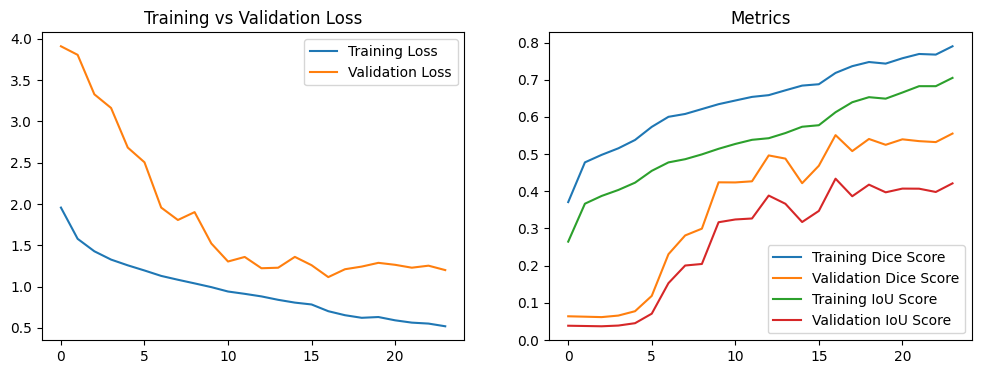

In [ ]:
def plot_history(history):

    history_data = history.history
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history_data.get('loss', []), label='Training Loss')
    plt.plot(history_data.get('val_loss', []), label='Validation Loss')
    plt.legend()
    plt.title('Training vs Validation Loss')

    plt.subplot(1, 2, 2)
    if 'mean_dice' in history_data:
        plt.plot(history_data['mean_dice'], label='Training Dice Score')
        plt.plot(history_data['val_mean_dice'], label='Validation Dice Score')

    if 'mean_iou' in history_data:
        plt.plot(history_data['mean_iou'], label='Training IoU Score')
        plt.plot(history_data['val_mean_iou'], label='Validation IoU Score')

    plt.legend()
    plt.title('Metrics')
    plt.show()

plot_history(history)


# Model Performance Evaluation (IoU, Dice, Confusion Matrix)
Generates predictions on the test set.

Computes per-class IoU and Dice scores.

Reports ground-truth vs predicted pixels per class.

Builds a confusion matrix to check class-level performance.

In [ ]:
def predict_on_indices(model, images, masks, indices, batch_size=BATCH_SIZE):
    preds = []
    trues = []
    for i in range(0, len(indices), batch_size):
        batch_idx = indices[i:i+batch_size]
        imgs = np.stack([preprocess_image(images[j]) for j in batch_idx], axis=0)
        msks = np.stack([masks[j] for j in batch_idx], axis=0)  # integer masks
        pred_probs = model.predict(imgs)
        pred_labels = np.argmax(pred_probs, axis=-1)
        preds.append(pred_labels)
        trues.append(msks)
    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    return preds, trues


preds, trues = predict_on_indices(model, images, masks, test_idx, batch_size=BATCH_SIZE)
print("Preds shape:", preds.shape, "Trues shape:", trues.shape)


def per_class_metrics(trues, preds, num_classes=NUM_CLASSES):
    results = {}
    for c in range(num_classes):
        true_mask = (trues == c)
        pred_mask = (preds == c)

        intersection = np.logical_and(true_mask, pred_mask).sum()
        union = np.logical_or(true_mask, pred_mask).sum()

        gt_pixels = true_mask.sum()
        pred_pixels = pred_mask.sum()

        iou = intersection / (union + 1e-7)
        dice = (2 * intersection) / (gt_pixels + pred_pixels + 1e-7)

        results[c] = {
            'iou': float(iou),
            'dice': float(dice),
            'gt_pixels': int(gt_pixels),
            'pred_pixels': int(pred_pixels),
        }
    return results


metrics_per_class = per_class_metrics(trues, preds)

for c, values in metrics_per_class.items():
    print(
        f"Class {c}: "
        f"IoU={values['iou']:.4f}, "
        f"Dice={values['dice']:.4f}, "
        f"GT Pixels={values['gt_pixels']}, "
        f"Pred Pixels={values['pred_pixels']}"
    )

# Confusion matrix will evaluate how well My model’s predictions are matching with the ground truth
y_true_flat = trues.flatten()
y_pred_flat = preds.flatten()
cm = confusion_matrix(y_true_flat, y_pred_flat, labels=list(range(NUM_CLASSES)))
print("Confusion matrix shape:", cm.shape)
print(cm)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Preds shape: (150, 128, 256) Trues shape: (150, 128, 256)
Class 0: IoU=0.7039, Dice=0.8262, GT Pixels=3312210, Pred Pixels=3186574
Class 1: IoU=0.5032, Dice=0.6695, GT Pixels=1054438, Pred Pixels=1245712
Class 2: IoU=0.2865, Dice=0.4454, GT Pixels=190979, Pred Pixels=178073
Class

# Segmentation Outputs (Image vs Ground Truth vs Prediction)
Displays side-by-side image, ground truth mask, and predicted mask.

Helps to visually compare the segmentation quality on test samples.

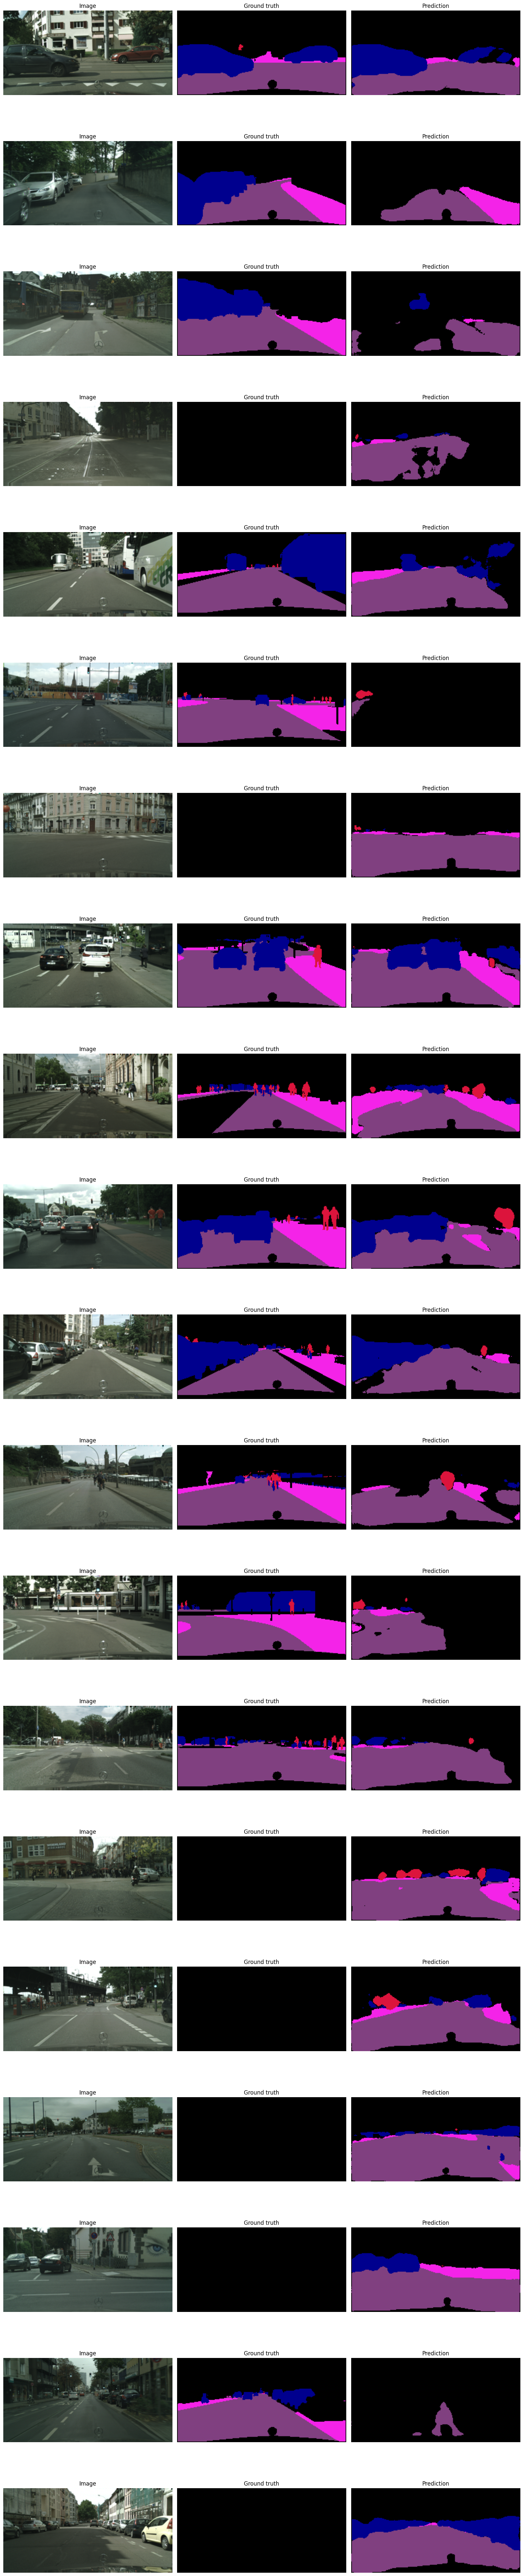

In [ ]:
CLASS_COLORS = {
    0: (0,0,0),
    1: (128,64,128),
    2: (244,35,232),
    3: (220,20,60),
    4: (0,0,142),}

def colorize_mask(mask):
    h,w = mask.shape
    rgb = np.zeros((h,w,3), dtype=np.uint8)
    for c, col in CLASS_COLORS.items():
        rgb[mask==c] = col
    return rgb

def show_examples(images, trues, preds, indices, n=6):
    plt.figure(figsize=(16, 4*n))
    for i in range(n):
        idx = indices[i]
        img = preprocess_image(images[idx])
        true_mask = trues[i]
        pred_mask = preds[i]
        ax = plt.subplot(n,3,3*i+1)
        ax.imshow(img)
        ax.set_title("Image")
        ax.axis('off')
        ax = plt.subplot(n,3,3*i+2)
        ax.imshow(colorize_mask(true_mask))
        ax.set_title("Ground truth")
        ax.axis('off')
        ax = plt.subplot(n,3,3*i+3)
        ax.imshow(colorize_mask(pred_mask))
        ax.set_title("Prediction")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Displaying examples from test set
show_examples(images, trues, preds, test_idx, n=min(20, len(test_idx)))
